In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20  # padding 또는 unknown
}

def random_voxel_rotate(voxel):
    # voxel: Tensor [C, D, H, W]
    if random.random() < 0.5:  # 50% 확률로 회전 적용
        axes = [(2, 3), (1, 3), (1, 2)]  # (H, W), (D, W), (D, H)
        k = random.choice([1, 2, 3])  # 실제 회전만 (0 제외)
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])  # D-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])  # H-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])  # W-axis flip
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, aug=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.aug = aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = row["MutPos"]
        wt = row["WT"]
        mut = row["Mut"]
        label = row["Label"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        # Load voxel
        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # shape: (1, 7, 7, 7, 63)

        # Preprocess
        feature_tensor = torch.from_numpy(feature).permute(0, 4, 1, 2, 3).float().squeeze(0)  # (63, 7, 7, 7)

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)

        # Convert WT/Mut AA to index
        ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
        mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)

        return feature_tensor, ref_idx, mut_idx, torch.tensor(label).float()
    
class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2  # 중심에서 양쪽 길이
        self.aug = aug
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = int(row["MutPos"]) - 1  # 1-based → 0-based
        label = float(row["Label"])
        mut = row["Mut"].upper()

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]  # 보통 첫 줄이 ref seq

        # 변이 반영된 mut_seq 생성
        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        # 사용될 시퀀스: 변이 시퀀스 + ref 시퀀스 + MSA
        seqs_to_use = [mut_seq, list(query_seq)]
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]  # 변이+ref 제외
            random.shuffle(msa_part)   # 순서 섞기
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                if 0 <= seq_idx < len(seq):
                    aa = seq[seq_idx]
                else:
                    aa = '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        # depth padding
        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)  # 20은 패딩 인덱스

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)  # [L, D]

        return {
            "msa": msa_tensor,  # [L, D]
            "label": torch.tensor(label).float()
        }

class MultimodalDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, msa_dict_path, 
                 voxel_aug=False, msa_aug=False, max_depth=80, win_size=61):
        self.df = df.reset_index(drop=True)
        self.voxel_dataset = VoxelDataset(df, voxel_cache_dir, aug=voxel_aug)
        self.msa_dataset = MSADataset(df, msa_dict_path, max_depth=max_depth, win_size=win_size, aug=msa_aug)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        voxel_feat, ref_idx, mut_idx, label = self.voxel_dataset[idx]
        msa_data = self.msa_dataset[idx]  # returns dict with "msa", "label"
        msa_tensor = msa_data["msa"]
        
        # 라벨 일치 확인 (안전용)
        assert label == msa_data["label"], "Mismatch in label!"

        return {
            "voxel": voxel_feat,      # [63, 7, 7, 7]
            "ref_idx": ref_idx,
            "mut_idx": mut_idx,
            "msa": msa_tensor,        # [L=61, D]
            "label": label
        }

In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
import torch.nn.functional as F
import numpy as np

class VoxelMBConvClassifier(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128, dropout_p=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]
        self.classifier = nn.Sequential(
            nn.Flatten(),                             # → [B, 128]
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(emb_dim, 1),
            nn.Sigmoid()  # Binary classification
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x.squeeze(-1)


class SqueezeExcitation3D(nn.Module):
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(self.pool(x))
        return x * scale

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=24):
        super().__init__()
        mid_ch = in_ch * expand_ratio

        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)

        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            return out + identity
        else:
            return out

# --- Input Embedding ---
class MSAInputEmbedding(nn.Module):
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x):  # x: (B, L, D)
        return self.embedding(x)  # → (B, L, D, C)

# --- MambaRMSNorm ---
class MambaRMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        norm = x.norm(dim=-1, keepdim=True) / (x.shape[-1] ** 0.5)
        return self.weight * x / (norm + self.eps)

# --- Cross-Axial Mamba Block ---
class CrossAxialMambaMSA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_L = MambaRMSNorm(dim)
        self.norm_D = MambaRMSNorm(dim)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Conv1d(in_channels=dim, out_channels=dim, kernel_size=5, padding=2)

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2  # = 30

        # --- D-axis: only at center L position ---
        x_d_center = self.norm_D(x[:, center_L])  # (B, D, C)
        x_d = x_d_center.transpose(1, 2)          # (B, C, D)
        d_out = self.conv_D(x_d).transpose(1, 2).unsqueeze(1)  # (B, 1, D, C)

        # --- L-axis: full Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3)  # (B, L, D, C)

        # --- Residual ---
        # d_out is only for center, rest is zero
        d_full = torch.zeros_like(x)
        d_full[:, center_L:center_L+1] = d_out

        return x + d_full + l_out
    
# # --- Encoder ---
class MSAEncoder(nn.Module):
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = MambaRMSNorm(dim)

    def forward(self, x):  # x: (B, L, D)
        x = self.embeddings(x)  # → (B, L, D, C)
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  # (B, L, D, C)



class VoxelBranch(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128):
        super().__init__()
        
        # 3D 구조 백본
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 32, expand_ratio=6),     # [7×7×7]
            MBConv3D(32, 32, expand_ratio=6),
            MBConv3D(32, 48, expand_ratio=6),
            MBConv3D(48, 48, expand_ratio=6),
            MBConv3D(48, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6, stride=2),  # 다운샘플링: → [4×4×4]
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]

        # Mutation Embedding (64 + 64 → 128)
        self.ref_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_fusion = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

        self.refine = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

    def forward(self, x, ref_idx, mut_idx):
        x = self.backbone(x)               # [B, 128, 7, 7, 7]
        x = self.pool(x).squeeze(-1).squeeze(-1).squeeze(-1)  # → [B, 128]

        # Mutation embedding
        ref_vec = self.ref_emb(ref_idx)    # [B, 64]
        mut_vec = self.mut_emb(mut_idx)    # [B, 64]
        mut_feat = self.mut_fusion(torch.cat([ref_vec, mut_vec], dim=1))  # [B, 128]

        # Combine structure & mutation features
        x = x + mut_feat                   # [B, 128]

        return self.refine(x)       # [B, 128]
    
class MSABranch(nn.Module):
    def __init__(self, num_layers=4, dim=128):
        super().__init__()

        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)

        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B, L, D, C)
        x = self.encoder(x) 
        
        center_L = x.shape[1] // 2   # 30
        x = x[:, center_L]           # (B, D, C)
        x = x.mean(dim=1)            # (B, C)
        return self.refine(x)        # (B, C=128)

class EvoStructCLIP(nn.Module):
    def __init__(self, voxel_ch=63, mb_layers=8, embed_dim=128, use_concat=True, dropout_p=0.3):
        super().__init__()
        self.voxel_encoder = VoxelBranch(in_ch=voxel_ch, emb_dim=embed_dim)
        self.msa_encoder = MSABranch(num_layers=mb_layers, dim=embed_dim)
        self.use_concat = use_concat

        # log(1 / 0.07) ≈ 2.6592 → exp(logit_scale) ≈ 14.2857
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        fused_dim = embed_dim * 2 if use_concat else embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.SiLU(),
            # nn.Dropout(dropout_p),
            nn.Linear(embed_dim, 1)
        )

    def _get_vector_norm(self, tensor: torch.Tensor) -> torch.Tensor:
        
        square_tensor = torch.pow(tensor, 2)
        sum_tensor = torch.sum(square_tensor, dim=-1, keepdim=True)
        normed_tensor = torch.pow(sum_tensor, 0.5)
        
        return normed_tensor

    def forward(self, voxel, ref_idx, mut_idx, msa):
        # Raw features
        voxel_feat = self.voxel_encoder(voxel, ref_idx, mut_idx)  # [B, 128]
        msa_feat = self.msa_encoder(msa)                          # [B, 128]

        voxel_embeds = voxel_feat / self._get_vector_norm(voxel_feat)
        msa_embeds = msa_feat / self._get_vector_norm(msa_feat)

        logits_per_voxel = torch.matmul(voxel_embeds, msa_embeds.t().to(voxel_embeds.device))
        logits_per_voxel = logits_per_voxel * self.logit_scale.exp().to(voxel_embeds.device)

        logits_per_msa = logits_per_voxel.t() 

        # For classification
        fused = torch.cat([voxel_feat, msa_feat], dim=-1) if self.use_concat else voxel_feat + msa_feat
        logits = self.classifier(fused)

        return {
            "logits": logits,
            "logits_per_msa": logits_per_msa,
            "logits_per_voxel": logits_per_voxel,
            "voxel_feat": voxel_feat,
            "msa_feat": msa_feat
        }

/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd

df = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/ARSA/sample_data.tsv", sep="\t")


from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42) 


voxel_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/voxel_cache"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid.pkl"


train_dataset = MultimodalDataset(df_train, voxel_cache_dir, msa_dict_path, voxel_aug=True, msa_aug=False)
val_dataset   = MultimodalDataset(df_val, voxel_cache_dir, msa_dict_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

Text(0.5, 1.0, 'Label distribution')

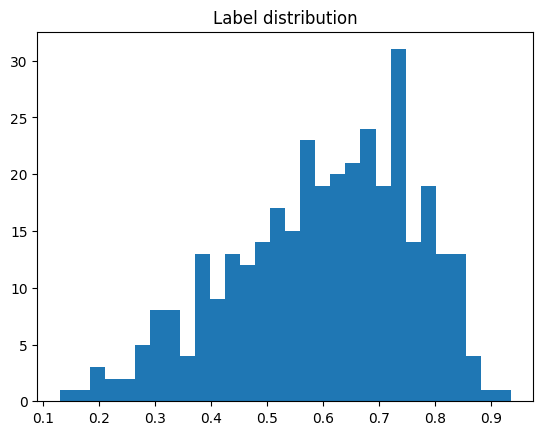

In [4]:
import matplotlib.pyplot as plt
plt.hist(df["Label"], bins=30)
plt.title("Label distribution")

In [5]:
min(df["Label"]), max(df["Label"])

(0.13, 0.935)

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, roc_auc_score
from scipy.stats import pearsonr, kendalltau
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=63, mb_layers=6, embed_dim=128, use_concat=True, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250806_clip.pth"))
model.eval()

fused_dim = 128 * 2 if model.use_concat else 128
model.classifier = nn.Sequential(
    nn.Linear(fused_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
).to(device)

val_loss = 0
all_probs = []
all_labels = []

# 1. Freeze all backbone layers
# for param in model.voxel_encoder.parameters():
#     param.requires_grad = False
# for param in model.msa_encoder.parameters():
#     param.requires_grad = False
# model.logit_scale.requires_grad = False

class PearsonLoss(nn.Module):
    def forward(self, pred, target):
        vx = pred - pred.mean()
        vy = target - target.mean()
        cost = torch.sum(vx * vy) / (torch.sqrt(torch.sum(vx ** 2)) * torch.sqrt(torch.sum(vy ** 2)) + 1e-8)
        return 1 - cost

# 2. Optimizer: head only
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=5e-3)
criterion_mse = nn.MSELoss()
criterion_pearson = PearsonLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-6)

# --- Contrastive loss
def contrastive_loss(logits: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(logits, torch.arange(len(logits), device=logits.device))

def compute_clip_loss(similarity: torch.Tensor) -> torch.Tensor:
    return (contrastive_loss(similarity) + contrastive_loss(similarity.t())) / 2

num_epochs = 1000
best_val_score = -np.inf
save_path = "/mnt/e/CAGI_data/best_ARSA_finetuned_250807.pth"

def fusemix(voxel_feat, msa_feat, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(voxel_feat.size(0), device=voxel_feat.device)

    voxel_feat_shuffled = voxel_feat[idx]
    msa_feat_shuffled = msa_feat[idx]

    voxel_mix = lam * voxel_feat + (1 - lam) * voxel_feat_shuffled
    msa_mix = lam * msa_feat + (1 - lam) * msa_feat_shuffled

    return voxel_mix, msa_mix

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        voxel = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa = batch["msa"].to(device)
        label = batch["label"].float().to(device)

        out = model(voxel, ref_idx, mut_idx, msa)

        voxel_feat = out["voxel_feat"]
        msa_feat = out["msa_feat"]

        # 원본 예측
        fused_orig = torch.cat([voxel_feat, msa_feat], dim=-1) if model.use_concat else voxel_feat + msa_feat
        logits_orig = model.classifier(fused_orig).squeeze(-1)
        loss_orig = criterion_mse(logits_orig, label) + compute_clip_loss(out["logits_per_voxel"]) + criterion_pearson(logits_orig, label)

        # FuseMix 적용
        voxel_mix, msa_mix = fusemix(voxel_feat, msa_feat)
        # fused_mix = torch.cat([voxel_mix, msa_mix], dim=-1) if model.use_concat else voxel_mix + msa_mix
        # logits_mix = model.classifier(fused_mix).squeeze(-1)

        voxel_mix_norm = voxel_mix / voxel_mix.norm(dim=-1, keepdim=True)
        msa_mix_norm = msa_mix / msa_mix.norm(dim=-1, keepdim=True)
        logits_per_voxel_mix = torch.matmul(voxel_mix_norm, msa_mix_norm.T) * model.logit_scale.exp()
        
        loss_mix = compute_clip_loss(logits_per_voxel_mix)

        # 총 손실
        loss = loss_orig + 0.7 * loss_mix

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * voxel.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)

    # === Validation ===
    model.eval()
    val_loss = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            voxel = batch["voxel"].to(device)
            ref_idx = batch["ref_idx"].to(device)
            mut_idx = batch["mut_idx"].to(device)
            msa = batch["msa"].to(device)
            label = batch["label"].float().to(device)

            out = model(voxel, ref_idx, mut_idx, msa)
            logits = out["logits"].squeeze(-1)
            
            loss = criterion_mse(logits, label) + 0.5 * criterion_pearson(logits, label)
            probs = logits
            
            val_loss += loss.item() * voxel.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    scheduler.step()

    avg_val_loss = val_loss / len(val_loader.dataset)
    pearson_r, _ = pearsonr(all_labels, all_probs)
    kendall_tau, _ = kendalltau(all_labels, all_probs)

    print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Pearson r: {pearson_r:.4f} | Kendall tau: {kendall_tau:.4f}")
    print(f"logits min: {min(all_probs):.4f}, max: {max(all_probs):.4f}")

    if pearson_r > best_val_score:
        best_val_score = pearson_r
        torch.save(model.state_dict(), save_path)
        print(f"✅ Saved new best model (val Pearson: {pearson_r:.4f})")

[Epoch 1] Train Loss: 1.2227 | Val Loss: 0.4962 | Pearson r: 0.4087 | Kendall tau: 0.2570
logits min: -0.0342, max: 0.4774
✅ Saved new best model (val Pearson: 0.4087)
[Epoch 2] Train Loss: 0.8488 | Val Loss: 0.2940 | Pearson r: 0.5118 | Kendall tau: 0.3242
logits min: 0.1198, max: 1.1306
✅ Saved new best model (val Pearson: 0.5118)
[Epoch 3] Train Loss: 0.6853 | Val Loss: 0.2570 | Pearson r: 0.5590 | Kendall tau: 0.3599
logits min: 0.0937, max: 1.0148
✅ Saved new best model (val Pearson: 0.5590)
[Epoch 4] Train Loss: 0.6112 | Val Loss: 0.2466 | Pearson r: 0.5630 | Kendall tau: 0.3599
logits min: 0.1961, max: 0.8888
✅ Saved new best model (val Pearson: 0.5630)
[Epoch 5] Train Loss: 0.5353 | Val Loss: 0.2589 | Pearson r: 0.5316 | Kendall tau: 0.3616
logits min: 0.1695, max: 0.8967
[Epoch 6] Train Loss: 0.4626 | Val Loss: 0.2444 | Pearson r: 0.5491 | Kendall tau: 0.3881
logits min: 0.1087, max: 0.9496
[Epoch 7] Train Loss: 0.5148 | Val Loss: 0.2446 | Pearson r: 0.5307 | Kendall tau: 0.37

KeyboardInterrupt: 

70

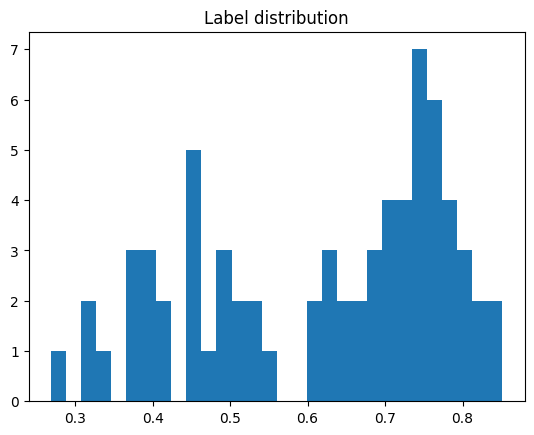

In [19]:
import matplotlib.pyplot as plt
plt.hist(all_labels, bins=30)
plt.title("Label distribution")
len(all_labels)

70

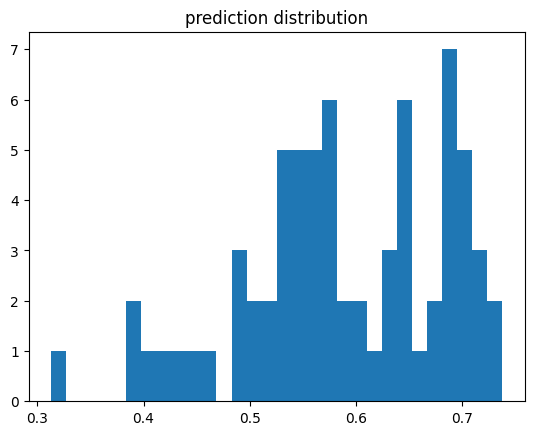

In [20]:
import matplotlib.pyplot as plt
plt.hist(all_probs, bins=30)
plt.title("prediction distribution")
len(all_probs)

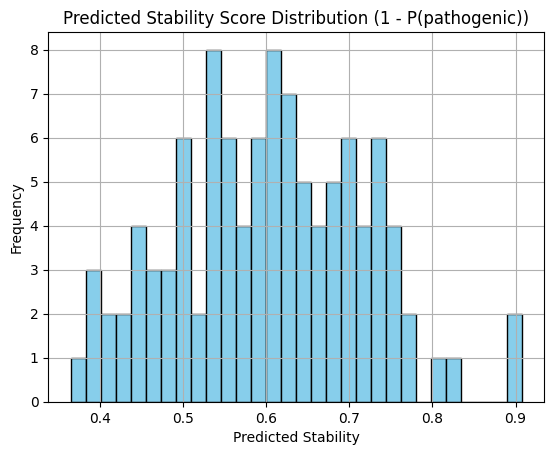

In [ ]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Stability Score Distribution (1 - P(pathogenic))")
plt.xlabel("Predicted Stability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
df

,UniProtID,MutPos,WT,Mut,Label,StructureFile
0,P15289,23,I,V,0.647,AF-P15289-F1-model_v4.pdb
1,P15289,29,D,N,0.575,AF-P15289-F1-model_v4.pdb
2,P15289,29,D,E,0.533,AF-P15289-F1-model_v4.pdb
3,P15289,30,D,H,0.459,AF-P15289-F1-model_v4.pdb
4,P15289,31,L,P,0.599,AF-P15289-F1-model_v4.pdb
...,...,...,...,...,...,...
344,P15289,494,T,I,0.734,AF-P15289-F1-model_v4.pdb
345,P15289,496,R,L,0.718,AF-P15289-F1-model_v4.pdb
346,P15289,496,R,H,0.796,AF-P15289-F1-model_v4.pdb
347,P15289,496,R,P,0.416,AF-P15289-F1-model_v4.pdb
